
Running experiment for N=1...

Running experiment for N=2...

Running experiment for N=3...

Running experiment for N=4...

Running experiment for N=5...

Running experiment for N=6...

Running experiment for N=7...

Running experiment for N=8...

========== Summary Table ==========
 N | #States  |   DP Time  |  DP Rew   | DP Bell Res |  DQN Time |  DQN Rew  | DQN Bell Res 
------------------------------------------------------------------------------------------
 1 |       6 |      0.00s |    -19.80 |     0.0000 |      5.11s |    -19.82 |      0.0310
 2 |      36 |      0.02s |    -39.66 |     0.0000 |      5.52s |    -39.69 |      0.2264
 3 |     216 |      0.29s |    -59.43 |     0.0000 |      9.23s |    -59.46 |      0.8374
 4 |    1296 |      3.81s |    -79.34 |     0.0000 |    101.18s |    -79.34 |      0.8344
 5 |    7776 |     45.97s |    -99.25 |     0.0000 |    154.62s |    -99.08 |      1.5720
 6 |   46656 |   2673.12s |   -118.86 |     0.0000 |    218.16s |   -119.06 |    

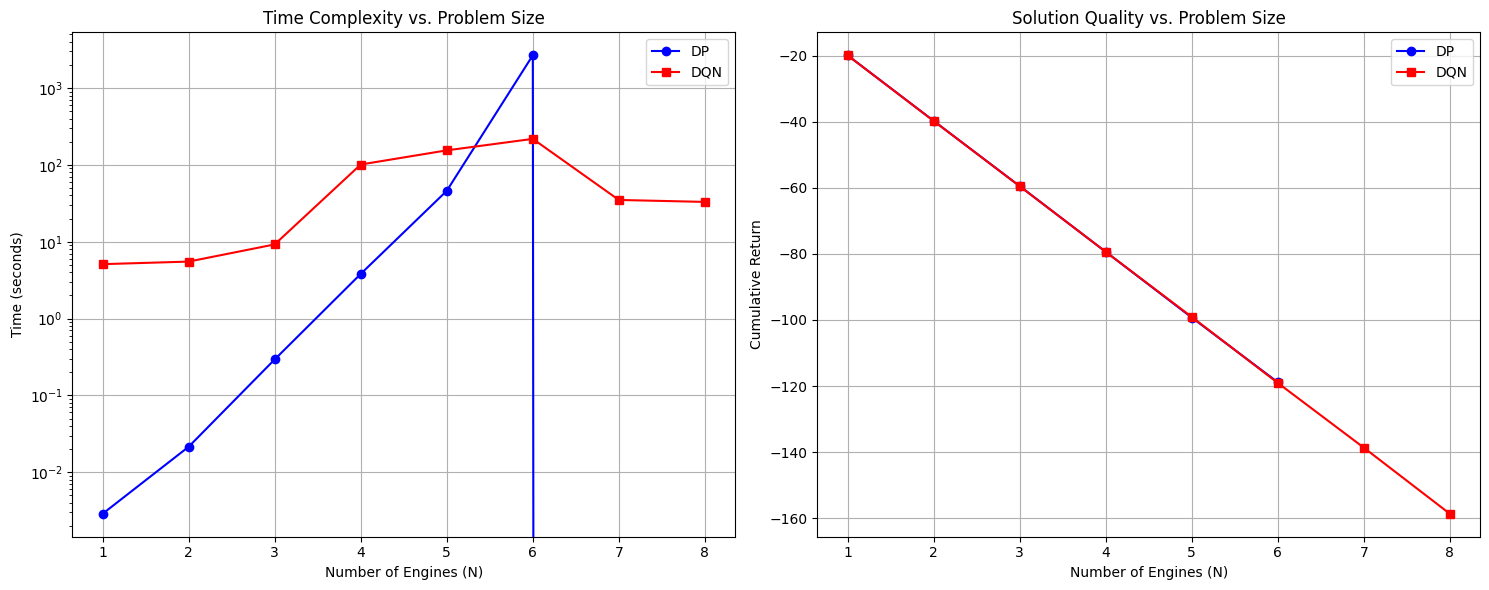

In [4]:
import numpy as np
import random
import time
import torch
import torch.nn as nn
import torch.optim as optim
from itertools import product, combinations
from collections import deque
import matplotlib.pyplot as plt

# ----------------- GLOBAL HYPERPARAMS ----------------- #
DISCOUNT = 0.95
MAX_MILEAGE = 5
CAPACITY = 3
ALPHA = 1.0
BETA = 5.0
N_DP_MAX = 6
DP_CUTOFF = 50_000

def step_state(s, action):
    """
    s      : tuple of engine mileages
    action : tuple of engine indices to replace
    Returns (next_state, reward)
    """
    N = len(s)
    replaced_count = len(action)
    old_count = sum(m > 0 for m in s)
    cost = ALPHA * old_count + BETA * replaced_count
    
    next_s = []
    for i in range(N):
        if i in action:
            next_s.append(0)
        else:
            next_s.append(min(MAX_MILEAGE, s[i] + 1))
    
    return tuple(next_s), -cost

def all_states(N):
    """Enumerate all possible states if N is small."""
    return list(product(range(MAX_MILEAGE + 1), repeat=N))

def all_actions(N):
    """All subsets of up to CAPACITY engines to replace."""
    acts = []
    for k in range(CAPACITY + 1):
        for combo in combinations(range(N), k):
            acts.append(combo)
    return acts

# ------------- Bellman Residual (Convergence Check) ------------- #
def bellman_error(qnet, N, discount=DISCOUNT, max_samples=10000):
    """
    Computes a mean absolute Bellman residual for Q(s,a):
      residual = |Q(s,a) - [r + discount * max_{a'} Q(s',a')]|.
    If #states <= max_samples, do full pass;
    otherwise randomly sample states.
    """
    states = all_states(N)
    actions = all_actions(N)
    n_states = len(states)
    # If the state space is too large, sample states:
    if n_states > max_samples:
        states = random.sample(states, max_samples)

    residuals = []
    for s in states:
        s_t = torch.FloatTensor(s)
        with torch.no_grad():
            qvals_s = qnet(s_t)  # shape [action_dim]
        for a_idx, a in enumerate(actions):
            Qsa_approx = qvals_s[a_idx].item()
            s_next, r = step_state(s, a)
            with torch.no_grad():
                qvals_next = qnet(torch.FloatTensor(s_next))
            Qsa_target = r + discount * qvals_next.max().item()
            residuals.append(abs(Qsa_approx - Qsa_target))
    return np.mean(residuals) if residuals else 0.0

# ------------- DP Convergence Check ------------- #
def check_dp_convergence(V, policy, N, discount=DISCOUNT, max_samples=10000):
    """
    Computes a mean absolute Bellman residual for the DP solution:
      residual = |V(s) - [r + discount * V(s')]|.
    """
    states = all_states(N)
    n_states = len(states)
    # If the state space is too large, sample states:
    if n_states > max_samples:
        states = random.sample(states, max_samples)
    
    residuals = []
    for s in states:
        a = policy[s]
        s_next, r = step_state(s, a)
        v_target = r + discount * V[s_next]
        v_current = V[s]
        residuals.append(abs(v_current - v_target))
    
    return np.mean(residuals) if residuals else 0.0

# ------------------ D P  (Value Iteration) ------------------ #
def value_iteration_dp(N, tol=1e-5, max_iter=1000):
    states = all_states(N)
    actions = all_actions(N)
    V = {s: 0.0 for s in states}
    policy = {s: actions[0] for s in states}
    
    convergence_history = []
    
    for it in range(max_iter):
        delta = 0
        newV = {}
        for s in states:
            best_val = float('-inf')
            best_a = None
            old_val = V[s]
            for a in actions:
                ns, r = step_state(s, a)
                val = r + DISCOUNT * V[ns]
                if val > best_val:
                    best_val = val
                    best_a = a
            newV[s] = best_val
            policy[s] = best_a
            delta = max(delta, abs(best_val - old_val))
        V = newV
        convergence_history.append(delta)
        if delta < tol:
            break
    
    return V, policy, convergence_history

def evaluate_dp(policy, N, episodes=100, max_steps=20):
    """Sample-based evaluation of DP policy."""
    returns = []
    for _ in range(episodes):
        s = tuple(random.randint(0, MAX_MILEAGE) for _ in range(N))
        ep_r = 0
        for _ in range(max_steps):
            a = policy[s]
            s2, r = step_state(s, a)
            ep_r += r
            s = s2
        returns.append(ep_r)
    return np.mean(returns), np.std(returns)

# ------------------ D Q N ------------------ #
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )
    def forward(self, x):
        return self.net(x.float())

class MultiEngineEnv:
    def __init__(self, N):
        self.N = N
        self.actions = all_actions(N)
        self.reset()
    def reset(self):
        self.state = tuple(random.randint(0, MAX_MILEAGE) for _ in range(self.N))
        return self.state
    def step(self, action_idx):
        a = self.actions[action_idx]
        next_s, r = step_state(self.state, a)
        self.state = next_s
        return next_s, r

def check_policy_stability(qnet_current, qnet_previous, N, sample_size=1000, threshold=0.01):
    """
    Check if the policy has stabilized by comparing actions between current and previous Q-networks.
    Returns True if policy is stable (few changes in best actions).
    """
    # Sample random states
    states = [tuple(random.randint(0, MAX_MILEAGE) for _ in range(N)) for _ in range(sample_size)]
    actions = all_actions(N)
    
    changes = 0
    for s in states:
        s_t = torch.FloatTensor(s)
        with torch.no_grad():
            old_q = qnet_previous(s_t)
            new_q = qnet_current(s_t)
        old_best = old_q.argmax().item()
        new_best = new_q.argmax().item()
        if old_best != new_best:
            changes += 1
    
    frac_changed = changes / sample_size
    return frac_changed < threshold, frac_changed  # True if policy is 'stable' enough

def check_performance_plateau(returns_history, window=10, epsilon=0.01):
    """
    Check if performance has plateaued by comparing rolling averages.
    Returns True if performance is stable.
    """
    # returns_history: list of recent episode returns
    if len(returns_history) < 2*window:
        return False, float('inf')  # Not enough data
    
    # Compare average of last window vs previous window
    recent_avg = sum(returns_history[-window:]) / window
    prev_avg = sum(returns_history[-2*window:-window]) / window
    diff = abs(recent_avg - prev_avg)
    return diff < epsilon, diff

def train_dqn(N, episodes=2000, gamma=DISCOUNT, lr=1e-3,
              batch_size=64, max_steps=20, check_interval=100):
    env = MultiEngineEnv(N)
    action_dim = len(env.actions)
    qnet = QNetwork(N, action_dim)
    tgt = QNetwork(N, action_dim)
    tgt.load_state_dict(qnet.state_dict())
    
    # For policy stability check
    import copy
    previous_qnet = copy.deepcopy(qnet)
    policy_check_interval = 50
    policy_stability_counter = 0
    required_stable_checks = 3  # Number of consecutive stable checks required
    
    # For performance plateau check
    eval_interval = 50
    returns_history = []
    plateau_counter = 0
    required_plateau_checks = 3  # Number of consecutive plateau checks required
    
    opt = optim.Adam(qnet.parameters(), lr=lr)
    mem = deque(maxlen=10000)
    
    epsilon = 1.0
    eps_min = 0.01
    eps_decay = 0.995
    
    loss_history = []
    bellman_history = []
    stability_history = []
    plateau_history = []
    
    for ep in range(episodes):
        s = env.reset()
        ep_reward = 0
        
        for _ in range(max_steps):
            # Epsilon-greedy
            if random.random() < epsilon:
                a_idx = random.randint(0, action_dim - 1)
            else:
                with torch.no_grad():
                    qs = qnet(torch.FloatTensor(s))
                a_idx = qs.argmax().item()
            s2, r = env.step(a_idx)
            mem.append((s, a_idx, r, s2))
            s = s2
            ep_reward += r
        
        # Training step
        if len(mem) >= batch_size:
            batch = random.sample(mem, batch_size)
            s_b, a_b, r_b, s2_b = zip(*batch)
            s_t = torch.FloatTensor(s_b)
            a_t = torch.LongTensor(a_b).unsqueeze(1)
            r_t = torch.FloatTensor(r_b).unsqueeze(1)
            s2_t = torch.FloatTensor(s2_b)
            
            qvals = qnet(s_t).gather(1, a_t)
            with torch.no_grad():
                maxq_next = tgt(s2_t).max(dim=1, keepdim=True)[0]
            target = r_t + gamma * maxq_next
            loss = nn.MSELoss()(qvals, target)
            
            opt.zero_grad()
            loss.backward()
            opt.step()
            
            loss_history.append(loss.item())
        
        # Update target
        if (ep + 1) % 50 == 0:
            tgt.load_state_dict(qnet.state_dict())
        
        # Check Bellman residual periodically
        if (ep + 1) % check_interval == 0 and N <= N_DP_MAX:
            residual = bellman_error(qnet, N, max_samples=min(1000, (MAX_MILEAGE + 1) ** N))
            bellman_history.append((ep, residual))
        
        # Policy stability check
        if (ep + 1) % policy_check_interval == 0:
            sample_size = min(1000, (MAX_MILEAGE + 1) ** N) if N <= N_DP_MAX else 1000
            is_stable, frac_changed = check_policy_stability(qnet, previous_qnet, N, sample_size=sample_size)
            stability_history.append((ep, frac_changed))
            
            if is_stable:
                policy_stability_counter += 1
            else:
                policy_stability_counter = 0
            
            # Update previous network for next check
            previous_qnet = copy.deepcopy(qnet)
        
        # Performance evaluation for plateau check
        if (ep + 1) % eval_interval == 0:
            eval_return, _ = evaluate_dqn(qnet, N, episodes=5)
            returns_history.append(eval_return)
            
            if len(returns_history) >= 2*10:  # Need at least 2 windows
                is_plateau, diff = check_performance_plateau(returns_history)
                plateau_history.append((ep, diff))
                
                if is_plateau:
                    plateau_counter += 1
                else:
                    plateau_counter = 0
        
        # Early stopping check
        if (policy_stability_counter >= required_stable_checks and 
            plateau_counter >= required_plateau_checks):
            print(f"Early stopping at episode {ep+1}: Policy stable and performance plateaued")
            break
        
        # Decay epsilon
        epsilon = max(eps_min, epsilon * eps_decay)
    
    return qnet, loss_history, bellman_history, stability_history, plateau_history, returns_history

def evaluate_dqn(qnet, N, episodes=100, max_steps=20):
    env = MultiEngineEnv(N)
    returns = []
    for _ in range(episodes):
        s = env.reset()
        ep_r = 0
        for _ in range(max_steps):
            with torch.no_grad():
                qs = qnet(torch.FloatTensor(s))
            a_idx = qs.argmax().item()
            s, r = env.step(a_idx)
            ep_r += r
        returns.append(ep_r)
    return np.mean(returns), np.std(returns)

def evaluate_dqn(qnet, N, episodes=100, max_steps=20):
    env = MultiEngineEnv(N)
    returns = []
    for _ in range(episodes):
        s = env.reset()
        ep_r = 0
        for _ in range(max_steps):
            with torch.no_grad():
                qs = qnet(torch.FloatTensor(s))
            a_idx = qs.argmax().item()
            s, r = env.step(a_idx)
            ep_r += r
        returns.append(ep_r)
    return np.mean(returns), np.std(returns)

# ------------------ VISUALIZATION FUNCTIONS ------------------ #
def plot_convergence(dp_history=None, dqn_bellman_history=None, dqn_loss_history=None, N=None):
    """Plot convergence metrics for both algorithms."""
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot DP convergence
    if dp_history is not None and len(dp_history) > 0:
        axes[0].plot(range(1, len(dp_history) + 1), dp_history, 'b-', label=f'DP Delta (N={N})')
        axes[0].set_xlabel('Iteration')
        axes[0].set_ylabel('Max Value Change (Delta)')
        axes[0].set_title('DP Convergence')
        axes[0].set_yscale('log')
        axes[0].grid(True)
        axes[0].legend()
    
    # Plot DQN convergence
    if dqn_loss_history is not None and len(dqn_loss_history) > 0:
        ax_loss = axes[1]
        ax_loss.plot(range(1, len(dqn_loss_history) + 1), dqn_loss_history, 'r-', alpha=0.5, label=f'Loss (N={N})')
        ax_loss.set_xlabel('Training Step')
        ax_loss.set_ylabel('Loss')
        ax_loss.set_title('DQN Training')
        ax_loss.grid(True)
        
        if dqn_bellman_history is not None and len(dqn_bellman_history) > 0:
            ax_bellman = ax_loss.twinx()
            episodes, residuals = zip(*dqn_bellman_history)
            ax_bellman.plot(episodes, residuals, 'g-', marker='o', label=f'Bellman Residual (N={N})')
            ax_bellman.set_ylabel('Bellman Residual')
            ax_bellman.tick_params(axis='y', labelcolor='g')
        
        lines, labels = ax_loss.get_legend_handles_labels()
        if dqn_bellman_history is not None and len(dqn_bellman_history) > 0:
            lines2, labels2 = ax_bellman.get_legend_handles_labels()
            lines += lines2
            labels += labels2
        ax_loss.legend(lines, labels, loc='upper right')
    
    plt.tight_layout()
    return fig

def plot_results(results):
    """Plot time taken and cumulative return for both algorithms as N increases."""
    N_list = [r['N'] for r in results]
    
    # Create a figure with 1x2 grid
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Time taken vs N
    axes[0].plot(N_list, [r['dp_time'] for r in results], 'bo-', label='DP')
    axes[0].plot(N_list, [r['dqn_time'] for r in results], 'rs-', label='DQN')
    axes[0].set_xlabel('Number of Engines (N)')
    axes[0].set_ylabel('Time (seconds)')
    axes[0].set_title('Time Complexity vs. Problem Size')
    axes[0].set_yscale('log')  # Log scale for better visualization
    axes[0].legend()
    axes[0].grid(True)
    
    # Plot 2: Cumulative return vs N
    dp_rewards = [r['dp_reward'] if r['dp_reward'] is not None else float('nan') for r in results]
    dqn_rewards = [r['dqn_reward'] for r in results]
    
    axes[1].plot(N_list, dp_rewards, 'bo-', label='DP')
    axes[1].plot(N_list, dqn_rewards, 'rs-', label='DQN')
    axes[1].set_xlabel('Number of Engines (N)')
    axes[1].set_ylabel('Cumulative Return')
    axes[1].set_title('Solution Quality vs. Problem Size')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    return fig

# ------------------ RUN EXPERIMENTS ------------------ #
def run_experiment(N, dqn_episodes=2000):
    n_states = (MAX_MILEAGE + 1) ** N
    
    dp_value, dp_policy = None, None
    dp_time = None
    dp_reward = None
    dp_residual = None
    dp_history = None
    
    # Possibly do DP if #states not too large.
    if (n_states <= DP_CUTOFF) and (N <= N_DP_MAX):
        t0 = time.time()
        dp_value, dp_policy, dp_history = value_iteration_dp(N)
        dp_time = time.time() - t0
        dp_reward, _ = evaluate_dp(dp_policy, N)
        
        # Check DP convergence using Bellman error
        dp_residual = check_dp_convergence(dp_value, dp_policy, N)
        
        # Plot DP convergence
        if N <= 3:  # Only plot for smaller values to keep runtime manageable
            plt.figure(figsize=(10, 6))
            plt.plot(range(1, len(dp_history) + 1), dp_history)
            plt.xlabel('Iteration')
            plt.ylabel('Max Value Change (Delta)')
            plt.title(f'DP Convergence for N={N}')
            plt.yscale('log')
            plt.grid(True)
            plt.savefig(f'dp_convergence_N{N}.png')
            plt.close()
    else:
        dp_time = 0.0
        dp_reward = None
        dp_residual = None
        dp_history = None
    
    # DQN
    t1 = time.time()
    qnet, dqn_loss_history, dqn_bellman_history, stability_history, plateau_history, returns_history = train_dqn(N, episodes=dqn_episodes)
    dqn_time = time.time() - t1
    dqn_reward, _ = evaluate_dqn(qnet, N)
    
    # Bellman residual check for DQN
    dqn_residual = bellman_error(qnet, N, max_samples=min(5000, n_states))
    
    # Calculate final policy stability
    final_stability = 1.0
    if len(stability_history) > 0:
        final_stability = stability_history[-1][1]
    
    # Calculate final performance plateau
    final_plateau = float('inf')
    if len(plateau_history) > 0:
        final_plateau = plateau_history[-1][1]
    
    # Plot DQN training metrics
    if N <= 3:  # Only plot for smaller values to keep runtime manageable
        # Plot traditional convergence metrics
        fig = plot_convergence(dp_history, dqn_bellman_history, dqn_loss_history, N)
        plt.savefig(f'convergence_metrics_N{N}.png')
        plt.close()
        
        # Plot new convergence checks
        plt.figure(figsize=(15, 6))
        plt.subplot(1, 2, 1)
        if stability_history:
            episodes, fractions = zip(*stability_history)
            plt.plot(episodes, fractions, 'bo-')
            plt.xlabel('Episode')
            plt.ylabel('Policy Change Fraction')
            plt.title('Policy Stability')
            plt.grid(True)
        
        plt.subplot(1, 2, 2)
        if len(returns_history) > 0:
            plt.plot(range(0, len(returns_history)*50, 50), returns_history, 'ro-')
            plt.xlabel('Episode')
            plt.ylabel('Evaluation Return')
            plt.title('Performance Curve')
            plt.grid(True)
        
        plt.tight_layout()
        plt.savefig(f'convergence_checks_N{N}.png')
        plt.close()
    
    return {
        'N': N,
        'n_states': n_states,
        'dp_time': dp_time,
        'dp_reward': dp_reward,
        'dp_residual': dp_residual,
        'dqn_time': dqn_time,
        'dqn_reward': dqn_reward,
        'dqn_residual': dqn_residual,
        'dqn_policy_stability': final_stability,
        'dqn_perf_plateau': final_plateau
    }

def main():
    np.random.seed(42)
    random.seed(42)
    torch.manual_seed(42)

    N_list = [1, 2, 3, 4, 5, 6, 7, 8]
    results = []
    
    for N in N_list:
        print(f"\nRunning experiment for N={N}...")
        res = run_experiment(N, dqn_episodes=15_000 if N>3 else 5000)
        results.append(res)
    
    # Print table
    print("\n========== Summary Table ==========")
    print(" N | #States  |   DP Time  |  DP Rew   | DP Bell Res |  DQN Time |  DQN Rew  | DQN Bell Res ")
    print("------------------------------------------------------------------------------------------")
    for r in results:
        dp_time_str = f"{r['dp_time']:.2f}s" if r['dp_time'] else "SKIP"
        dp_reward_str = f"{r['dp_reward']:.2f}" if r['dp_reward'] is not None else "SKIP"
        dp_residual_str = f"{r['dp_residual']:.4f}" if r['dp_residual'] is not None else "SKIP"
        
        print(f" {r['N']} | {r['n_states']:>7} | {dp_time_str:>10} | {dp_reward_str:>9} | "
              f"{dp_residual_str:>10} | {r['dqn_time']:>9.2f}s | {r['dqn_reward']:>9.2f} | {r['dqn_residual']:>11.4f}")
    
    # Plot comparison results
    fig = plot_results(results)
    plt.savefig('dp_vs_dqn_comparison.png')
    plt.show()

if __name__ == "__main__":
    main()


Running experiment for N=1...
Early stopping at episode 1500: Policy stable and performance plateaued

Running experiment for N=2...
Early stopping at episode 1250: Policy stable and performance plateaued

Running experiment for N=3...
Early stopping at episode 3300: Policy stable and performance plateaued

Running experiment for N=4...
Early stopping at episode 3400: Policy stable and performance plateaued

Running experiment for N=5...
Early stopping at episode 11050: Policy stable and performance plateaued

Running experiment for N=6...
Early stopping at episode 4300: Policy stable and performance plateaued

Running experiment for N=7...

Running experiment for N=8...
Projected DP time for N=7: 6418.84 seconds (~1.78 hours)
Projected DP time for N=8: 78561.36 seconds (~21.82 hours)

========== Summary Table ==========
 N | #States  |   DP Time  |  DP Rew   | DP Bell Res |  DQN Time |  DQN Rew  | DQN Bell Res | Policy Stab | Perf Plateau
---------------------------------------------

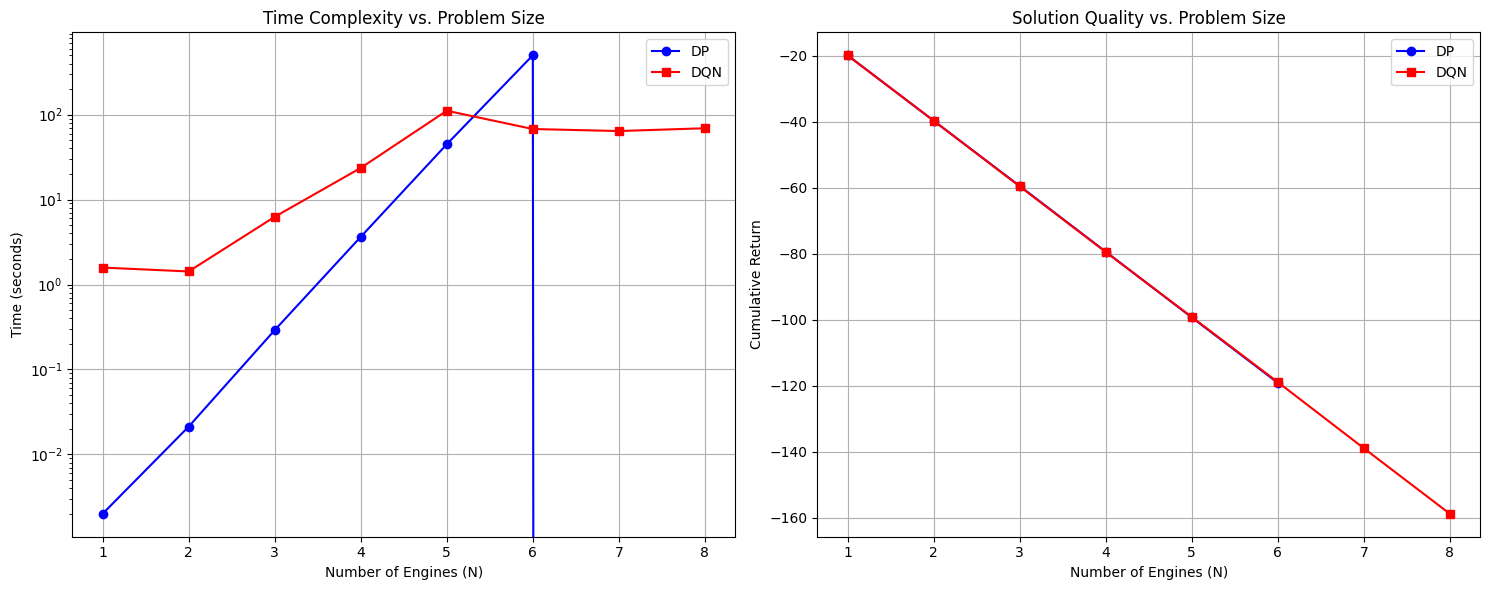

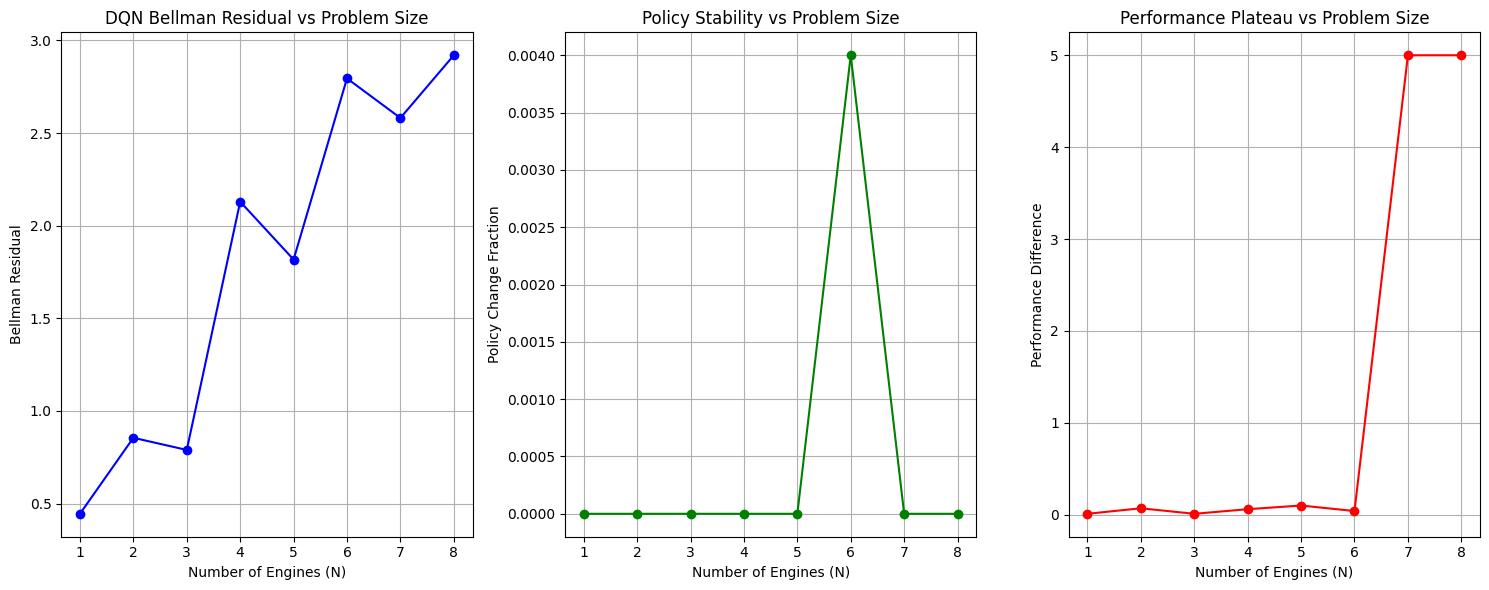

In [7]:
import numpy as np
import random
import time
import torch
import torch.nn as nn
import torch.optim as optim
from itertools import product, combinations
from collections import deque
import matplotlib.pyplot as plt

# ----------------- GLOBAL HYPERPARAMS ----------------- #
DISCOUNT = 0.95
MAX_MILEAGE = 5
CAPACITY = 3
ALPHA = 1.0
BETA = 5.0
N_DP_MAX = 6
DP_CUTOFF = 50_000

def step_state(s, action):
    """
    s      : tuple of engine mileages
    action : tuple of engine indices to replace
    Returns (next_state, reward)
    """
    N = len(s)
    replaced_count = len(action)
    old_count = sum(m > 0 for m in s)
    cost = ALPHA * old_count + BETA * replaced_count
    
    next_s = []
    for i in range(N):
        if i in action:
            next_s.append(0)
        else:
            next_s.append(min(MAX_MILEAGE, s[i] + 1))
    
    return tuple(next_s), -cost

def all_states(N):
    """Enumerate all possible states if N is small."""
    return list(product(range(MAX_MILEAGE + 1), repeat=N))

def all_actions(N):
    """All subsets of up to CAPACITY engines to replace."""
    acts = []
    for k in range(CAPACITY + 1):
        for combo in combinations(range(N), k):
            acts.append(combo)
    return acts

# ------------- Bellman Residual (Convergence Check) ------------- #
def bellman_error(qnet, N, discount=DISCOUNT, max_samples=10000):
    """
    Computes a mean absolute Bellman residual for Q(s,a):
      residual = |Q(s,a) - [r + discount * max_{a'} Q(s',a')]|.
    If #states <= max_samples, do full pass;
    otherwise randomly sample states.
    """
    states = all_states(N)
    actions = all_actions(N)
    n_states = len(states)
    # If the state space is too large, sample states:
    if n_states > max_samples:
        states = random.sample(states, max_samples)

    residuals = []
    for s in states:
        s_t = torch.FloatTensor(s)
        with torch.no_grad():
            qvals_s = qnet(s_t)  # shape [action_dim]
        for a_idx, a in enumerate(actions):
            Qsa_approx = qvals_s[a_idx].item()
            s_next, r = step_state(s, a)
            with torch.no_grad():
                qvals_next = qnet(torch.FloatTensor(s_next))
            Qsa_target = r + discount * qvals_next.max().item()
            residuals.append(abs(Qsa_approx - Qsa_target))
    return np.mean(residuals) if residuals else 0.0

# ------------- DP Convergence Check ------------- #
def check_dp_convergence(V, policy, N, discount=DISCOUNT, max_samples=10000):
    """
    Computes a mean absolute Bellman residual for the DP solution:
      residual = |V(s) - [r + discount * V(s')]|.
    """
    states = all_states(N)
    n_states = len(states)
    # If the state space is too large, sample states:
    if n_states > max_samples:
        states = random.sample(states, max_samples)
    
    residuals = []
    for s in states:
        a = policy[s]
        s_next, r = step_state(s, a)
        v_target = r + discount * V[s_next]
        v_current = V[s]
        residuals.append(abs(v_current - v_target))
    
    return np.mean(residuals) if residuals else 0.0

# ------------------ D P  (Value Iteration) ------------------ #
def value_iteration_dp(N, tol=1e-5, max_iter=1000):
    states = all_states(N)
    actions = all_actions(N)
    V = {s: 0.0 for s in states}
    policy = {s: actions[0] for s in states}
    
    convergence_history = []
    
    for it in range(max_iter):
        delta = 0
        newV = {}
        for s in states:
            best_val = float('-inf')
            best_a = None
            old_val = V[s]
            for a in actions:
                ns, r = step_state(s, a)
                val = r + DISCOUNT * V[ns]
                if val > best_val:
                    best_val = val
                    best_a = a
            newV[s] = best_val
            policy[s] = best_a
            delta = max(delta, abs(best_val - old_val))
        V = newV
        convergence_history.append(delta)
        if delta < tol:
            break
    
    return V, policy, convergence_history

def evaluate_dp(policy, N, episodes=100, max_steps=20):
    """Sample-based evaluation of DP policy."""
    returns = []
    for _ in range(episodes):
        s = tuple(random.randint(0, MAX_MILEAGE) for _ in range(N))
        ep_r = 0
        for _ in range(max_steps):
            a = policy[s]
            s2, r = step_state(s, a)
            ep_r += r
            s = s2
        returns.append(ep_r)
    return np.mean(returns), np.std(returns)

# ------------------ D Q N ------------------ #
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )
    def forward(self, x):
        return self.net(x.float())

class MultiEngineEnv:
    def __init__(self, N):
        self.N = N
        self.actions = all_actions(N)
        self.reset()
    def reset(self):
        self.state = tuple(random.randint(0, MAX_MILEAGE) for _ in range(self.N))
        return self.state
    def step(self, action_idx):
        a = self.actions[action_idx]
        next_s, r = step_state(self.state, a)
        self.state = next_s
        return next_s, r

def check_policy_stability(qnet_current, qnet_previous, N, sample_size=1000, threshold=0.02):
    """
    Check if the policy has stabilized by comparing actions between current and previous Q-networks.
    Returns True if policy is stable (few changes in best actions).
    """
    # Sample random states
    states = [tuple(random.randint(0, MAX_MILEAGE) for _ in range(N)) for _ in range(sample_size)]
    
    changes = 0
    for s in states:
        s_t = torch.FloatTensor(s)
        with torch.no_grad():
            old_q = qnet_previous(s_t)
            new_q = qnet_current(s_t)
        old_best = old_q.argmax().item()
        new_best = new_q.argmax().item()
        if old_best != new_best:
            changes += 1
    
    frac_changed = changes / sample_size
    return frac_changed < threshold, frac_changed  # True if policy is 'stable' enough

def check_performance_plateau(returns_history, window=10, epsilon=0.1):
    """
    Check if performance has plateaued by comparing rolling averages.
    Returns True if performance is stable.
    """
    # returns_history: list of recent episode returns
    if len(returns_history) < 2*window:
        return False, float('inf')  # Not enough data
    
    # Compare average of last window vs previous window
    recent_avg = sum(returns_history[-window:]) / window
    prev_avg = sum(returns_history[-2*window:-window]) / window
    diff = abs(recent_avg - prev_avg)
    return diff < epsilon, diff

def train_dqn(N, episodes=2000, gamma=DISCOUNT, lr=1e-3,
              batch_size=64, max_steps=20, check_interval=100, 
              early_stop=True, stability_threshold=0.02):
    env = MultiEngineEnv(N)
    action_dim = len(env.actions)
    qnet = QNetwork(N, action_dim)
    tgt = QNetwork(N, action_dim)
    tgt.load_state_dict(qnet.state_dict())
    
    # For policy stability check
    import copy
    previous_qnet = copy.deepcopy(qnet)
    policy_check_interval = 50
    policy_stability_counter = 0
    required_stable_checks = 5  # Rigorous criteria - need 5 consecutive stable checks
    
    # For performance plateau check
    eval_interval = 50
    returns_history = []
    plateau_counter = 0
    required_plateau_checks = 5  # Rigorous criteria - need 5 consecutive plateau checks
    
    opt = optim.Adam(qnet.parameters(), lr=lr)
    mem = deque(maxlen=10000)
    
    epsilon = 1.0
    eps_min = 0.01
    eps_decay = 0.995
    
    loss_history = []
    bellman_history = []
    stability_history = []
    plateau_history = []
    
    for ep in range(episodes):
        s = env.reset()
        ep_reward = 0
        
        for _ in range(max_steps):
            # Epsilon-greedy
            if random.random() < epsilon:
                a_idx = random.randint(0, action_dim - 1)
            else:
                with torch.no_grad():
                    qs = qnet(torch.FloatTensor(s))
                a_idx = qs.argmax().item()
            s2, r = env.step(a_idx)
            mem.append((s, a_idx, r, s2))
            s = s2
            ep_reward += r
        
        # Training step
        if len(mem) >= batch_size:
            batch = random.sample(mem, batch_size)
            s_b, a_b, r_b, s2_b = zip(*batch)
            s_t = torch.FloatTensor(s_b)
            a_t = torch.LongTensor(a_b).unsqueeze(1)
            r_t = torch.FloatTensor(r_b).unsqueeze(1)
            s2_t = torch.FloatTensor(s2_b)
            
            qvals = qnet(s_t).gather(1, a_t)
            with torch.no_grad():
                maxq_next = tgt(s2_t).max(dim=1, keepdim=True)[0]
            target = r_t + gamma * maxq_next
            loss = nn.MSELoss()(qvals, target)
            
            opt.zero_grad()
            loss.backward()
            opt.step()
            
            loss_history.append(loss.item())
        
        # Update target
        if (ep + 1) % 50 == 0:
            tgt.load_state_dict(qnet.state_dict())
        
        # Check Bellman residual periodically
        if (ep + 1) % check_interval == 0 and N <= N_DP_MAX:
            residual = bellman_error(qnet, N, max_samples=min(1000, (MAX_MILEAGE + 1) ** N))
            bellman_history.append((ep, residual))
        
        # Policy stability check
        if (ep + 1) % policy_check_interval == 0:
            sample_size = min(1000, (MAX_MILEAGE + 1) ** N) if N <= N_DP_MAX else 1000
            is_stable, frac_changed = check_policy_stability(qnet, previous_qnet, N, sample_size=sample_size, threshold=stability_threshold)
            stability_history.append((ep, frac_changed))
            
            if is_stable:
                policy_stability_counter += 1
            else:
                policy_stability_counter = 0
            
            # Update previous network for next check
            previous_qnet = copy.deepcopy(qnet)
        
        # Performance evaluation for plateau check
        if (ep + 1) % eval_interval == 0:
            eval_return, _ = evaluate_dqn(qnet, N, episodes=10)  # More episodes for stable estimates
            returns_history.append(eval_return)
            
            if len(returns_history) >= 2*10:  # Need at least 2 windows
                is_plateau, diff = check_performance_plateau(returns_history, epsilon=0.1)
                plateau_history.append((ep, diff))
                
                if is_plateau:
                    plateau_counter += 1
                else:
                    plateau_counter = 0
        
        # Early stopping check - only if enabled and we've seen enough episodes
        min_episodes = 500 if N <= 6 else 1000  # Ensure minimum training even with early stopping
        if early_stop and ep >= min_episodes and (policy_stability_counter >= required_stable_checks and 
                          plateau_counter >= required_plateau_checks):
            print(f"Early stopping at episode {ep+1}: Policy stable and performance plateaued")
            break
        
        # Decay epsilon
        epsilon = max(eps_min, epsilon * eps_decay)
    
    # Always do a final evaluation for metrics
    eval_return, _ = evaluate_dqn(qnet, N, episodes=50)
    if not returns_history or returns_history[-1] != eval_return:
        returns_history.append(eval_return)
    
    # Always check final Bellman residual for metrics
    final_residual = bellman_error(qnet, N, max_samples=min(5000, (MAX_MILEAGE + 1) ** N))
    if not bellman_history or bellman_history[-1][1] != final_residual:
        bellman_history.append((episodes-1, final_residual))
    
    return qnet, loss_history, bellman_history, stability_history, plateau_history, returns_history

def evaluate_dqn(qnet, N, episodes=100, max_steps=20):
    env = MultiEngineEnv(N)
    returns = []
    for _ in range(episodes):
        s = env.reset()
        ep_r = 0
        for _ in range(max_steps):
            with torch.no_grad():
                qs = qnet(torch.FloatTensor(s))
            a_idx = qs.argmax().item()
            s, r = env.step(a_idx)
            ep_r += r
        returns.append(ep_r)
    return np.mean(returns), np.std(returns)

# Function to project DP time based on existing data
def project_dp_time(results, N_to_project):
    """
    Use log-linear regression to project DP time for larger N values.
    """
    import numpy as np
    from scipy import stats
    
    # Filter out results where DP was skipped
    dp_data = [(r['N'], r['dp_time']) for r in results if r['dp_time'] > 0]
    if len(dp_data) < 2:
        return None  # Not enough data points for regression
    
    # Extract N and time values
    N_values, time_values = zip(*dp_data)
    
    # Log transform the time values for linear regression
    log_times = np.log(time_values)
    
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(N_values, log_times)
    
    # Project the time for the requested N
    projected_log_time = slope * N_to_project + intercept
    projected_time = np.exp(projected_log_time)
    
    return projected_time

# ------------------ RUN EXPERIMENTS ------------------ #
def run_experiment(N, dqn_episodes=2000, skip_dp=False):
    n_states = (MAX_MILEAGE + 1) ** N
    
    dp_value, dp_policy = None, None
    dp_time = None
    dp_reward = None
    dp_residual = None
    dp_history = None
    
    # Possibly do DP if #states not too large and not explicitly skipped
    if (n_states <= DP_CUTOFF) and (N <= N_DP_MAX) and not skip_dp:
        t0 = time.time()
        dp_value, dp_policy, dp_history = value_iteration_dp(N)
        dp_time = time.time() - t0
        dp_reward, _ = evaluate_dp(dp_policy, N)
        
        # Check DP convergence using Bellman error
        dp_residual = check_dp_convergence(dp_value, dp_policy, N)
        
        # Plot DP convergence
        if N <= 3:  # Only plot for smaller values to keep runtime manageable
            plt.figure(figsize=(10, 6))
            plt.plot(range(1, len(dp_history) + 1), dp_history)
            plt.xlabel('Iteration')
            plt.ylabel('Max Value Change (Delta)')
            plt.title(f'DP Convergence for N={N}')
            plt.yscale('log')
            plt.grid(True)
            plt.savefig(f'dp_convergence_N{N}.png')
            plt.close()
    else:
        dp_time = 0.0
        dp_reward = None
        dp_residual = None
        dp_history = None
    
    # DQN - increase episodes for larger N to ensure convergence
    adjusted_episodes = dqn_episodes
    if N >= 7:
        adjusted_episodes = max(dqn_episodes, 25_000)
    
    # Use early stopping but with rigorous criteria
    early_stop = True  # We want early stopping with rigorous criteria for all N
    
    t1 = time.time()
    qnet, dqn_loss_history, dqn_bellman_history, stability_history, plateau_history, returns_history = train_dqn(
        N, 
        episodes=adjusted_episodes, 
        early_stop=early_stop,
        stability_threshold=0.02  # Threshold for policy change fraction
    )
    dqn_time = time.time() - t1
    dqn_reward, _ = evaluate_dqn(qnet, N, episodes=100)  # More episodes for final evaluation
    
    # Bellman residual check for DQN
    dqn_residual = bellman_error(qnet, N, max_samples=min(5000, n_states))
    
    # Calculate final policy stability
    final_stability = 1.0
    if len(stability_history) > 0:
        final_stability = stability_history[-1][1]
    
    # Calculate final performance plateau
    final_plateau = float('inf')
    if len(plateau_history) > 0:
        final_plateau = plateau_history[-1][1]
    
    # Plot DQN training metrics
    if N <= 3:  # Only plot for smaller values to keep runtime manageable
        # Plot traditional convergence metrics
        fig = plot_convergence(dp_history, dqn_bellman_history, dqn_loss_history, N)
        plt.savefig(f'convergence_metrics_N{N}.png')
        plt.close()
        
        # Plot new convergence checks
        plt.figure(figsize=(15, 6))
        plt.subplot(1, 2, 1)
        if stability_history:
            episodes, fractions = zip(*stability_history)
            plt.plot(episodes, fractions, 'bo-')
            plt.xlabel('Episode')
            plt.ylabel('Policy Change Fraction')
            plt.title('Policy Stability')
            plt.grid(True)
        
        plt.subplot(1, 2, 2)
        if len(returns_history) > 0:
            plt.plot(range(0, len(returns_history)*50, 50), returns_history, 'ro-')
            plt.xlabel('Episode')
            plt.ylabel('Evaluation Return')
            plt.title('Performance Curve')
            plt.grid(True)
        
        plt.tight_layout()
        plt.savefig(f'convergence_checks_N{N}.png')
        plt.close()
    
    return {
        'N': N,
        'n_states': n_states,
        'dp_time': dp_time,
        'dp_reward': dp_reward,
        'dp_residual': dp_residual,
        'dqn_time': dqn_time,
        'dqn_reward': dqn_reward,
        'dqn_residual': dqn_residual,
        'dqn_policy_stability': final_stability,
        'dqn_perf_plateau': final_plateau
    }

def plot_convergence(dp_history=None, dqn_bellman_history=None, dqn_loss_history=None, N=None):
    """Plot convergence metrics for both algorithms."""
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot DP convergence
    if dp_history is not None and len(dp_history) > 0:
        axes[0].plot(range(1, len(dp_history) + 1), dp_history, 'b-', label=f'DP Delta (N={N})')
        axes[0].set_xlabel('Iteration')
        axes[0].set_ylabel('Max Value Change (Delta)')
        axes[0].set_title('DP Convergence')
        axes[0].set_yscale('log')
        axes[0].grid(True)
        axes[0].legend()
    
    # Plot DQN convergence
    if dqn_loss_history is not None and len(dqn_loss_history) > 0:
        ax_loss = axes[1]
        ax_loss.plot(range(1, len(dqn_loss_history) + 1), dqn_loss_history, 'r-', alpha=0.5, label=f'Loss (N={N})')
        ax_loss.set_xlabel('Training Step')
        ax_loss.set_ylabel('Loss')
        ax_loss.set_title('DQN Training')
        ax_loss.grid(True)
        
        if dqn_bellman_history is not None and len(dqn_bellman_history) > 0:
            ax_bellman = ax_loss.twinx()
            episodes, residuals = zip(*dqn_bellman_history)
            ax_bellman.plot(episodes, residuals, 'g-', marker='o', label=f'Bellman Residual (N={N})')
            ax_bellman.set_ylabel('Bellman Residual')
            ax_bellman.tick_params(axis='y', labelcolor='g')
        
        lines, labels = ax_loss.get_legend_handles_labels()
        if dqn_bellman_history is not None and len(dqn_bellman_history) > 0:
            lines2, labels2 = ax_bellman.get_legend_handles_labels()
            lines += lines2
            labels += labels2
        ax_loss.legend(lines, labels, loc='upper right')
    
    plt.tight_layout()
    return fig

def plot_results(results, projected_dp_times=None):
    """Plot time taken and cumulative return for both algorithms as N increases."""
    N_list = [r['N'] for r in results]
    
    # Create a figure with 1x2 grid
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Time taken vs N
    axes[0].plot(N_list, [r['dp_time'] for r in results], 'bo-', label='DP')
    axes[0].plot(N_list, [r['dqn_time'] for r in results], 'rs-', label='DQN')
    
    # Add projected DP times if available
    if projected_dp_times:
        for N, time in projected_dp_times.items():
            if N not in N_list:  # Only add if not already in results
                axes[0].plot(N, time, 'bx', markersize=10, mew=2)
                axes[0].text(N, time*1.1, f"~{time:.0f}s\n(projected)", 
                           ha='center', va='bottom', fontsize=9, color='blue')
    
    axes[0].set_xlabel('Number of Engines (N)')
    axes[0].set_ylabel('Time (seconds)')
    axes[0].set_title('Time Complexity vs. Problem Size')
    axes[0].set_yscale('log')  # Log scale for better visualization
    axes[0].legend()
    axes[0].grid(True)
    
    # Plot 2: Cumulative return vs N
    dp_rewards = [r['dp_reward'] if r['dp_reward'] is not None else float('nan') for r in results]
    dqn_rewards = [r['dqn_reward'] for r in results]
    
    axes[1].plot(N_list, dp_rewards, 'bo-', label='DP')
    axes[1].plot(N_list, dqn_rewards, 'rs-', label='DQN')
    axes[1].set_xlabel('Number of Engines (N)')
    axes[1].set_ylabel('Cumulative Return')
    axes[1].set_title('Solution Quality vs. Problem Size')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    return fig

def main():
    np.random.seed(42)
    random.seed(42)
    torch.manual_seed(42)

    # Include N=7 and N=8 in the experiments
    N_list = [1, 2, 3, 4, 5, 6, 7, 8]
    results = []
    
    for N in N_list:
        print(f"\nRunning experiment for N={N}...")
        # Skip DP for N ≥ 7
        skip_dp = (N >= 7)
        
        # Adjust episodes by problem size
        if N <= 3:
            episodes = 5000
        elif N <= 6:
            episodes = 15000
        else:
            episodes = 25000
            
        res = run_experiment(N, dqn_episodes=episodes, skip_dp=skip_dp)
        results.append(res)
    
    # Project DP time for larger N values
    projected_dp_times = {}
    for N in [7, 8]:
        projected_time = project_dp_time(results[:6], N)  # Use only N=1 to N=6 for projection
        if projected_time:
            projected_dp_times[N] = projected_time
            print(f"Projected DP time for N={N}: {projected_time:.2f} seconds (~{projected_time/3600:.2f} hours)")
    
    # Print table with convergence checks
    print("\n========== Summary Table ==========")
    print(" N | #States  |   DP Time  |  DP Rew   | DP Bell Res |  DQN Time |  DQN Rew  | DQN Bell Res | Policy Stab | Perf Plateau")
    print("-----------------------------------------------------------------------------------------------------------")
    for r in results:
        if r['dp_time'] > 0:
            dp_time_str = f"{r['dp_time']:.2f}s"
        elif r['N'] in projected_dp_times:
            proj_time = projected_dp_times[r['N']]
            dp_time_str = f"~{proj_time:.2f}s (proj)"
        else:
            dp_time_str = "SKIP"
            
        dp_reward_str = f"{r['dp_reward']:.2f}" if r['dp_reward'] is not None else "SKIP"
        dp_residual_str = f"{r['dp_residual']:.4f}" if r['dp_residual'] is not None else "SKIP"
        
        print(f" {r['N']} | {r['n_states']:>7} | {dp_time_str:>12} | {dp_reward_str:>9} | "
              f"{dp_residual_str:>10} | {r['dqn_time']:>9.2f}s | {r['dqn_reward']:>9.2f} | {r['dqn_residual']:>11.4f} | "
              f"{r['dqn_policy_stability']:>10.4f} | {r['dqn_perf_plateau']:>11.4f}")
    
    # Plot comparison results with projected times
    fig = plot_results(results, projected_dp_times)
    plt.savefig('dp_vs_dqn_comparison.png')
    plt.show()
    
    # Create a figure to visualize convergence metrics across problem sizes
    plt.figure(figsize=(15, 6))
    
    # Plot 1: DQN Bellman Residual vs N
    plt.subplot(1, 3, 1)
    Ns = [r['N'] for r in results]
    bellman_residuals = [r['dqn_residual'] for r in results]
    plt.plot(Ns, bellman_residuals, 'bo-')
    plt.xlabel('Number of Engines (N)')
    plt.ylabel('Bellman Residual')
    plt.title('DQN Bellman Residual vs Problem Size')
    plt.grid(True)
    
    # Plot 2: Policy Stability vs N
    plt.subplot(1, 3, 2)
    policy_stabilities = [r['dqn_policy_stability'] for r in results]
    plt.plot(Ns, policy_stabilities, 'go-')
    plt.xlabel('Number of Engines (N)')
    plt.ylabel('Policy Change Fraction')
    plt.title('Policy Stability vs Problem Size')
    plt.grid(True)
    
    # Plot 3: Performance Plateau vs N
    plt.subplot(1, 3, 3)
    perf_plateaus = [min(r['dqn_perf_plateau'], 5.0) for r in results]  # Cap at 5.0 for better visualization
    plt.plot(Ns, perf_plateaus, 'ro-')
    plt.xlabel('Number of Engines (N)')
    plt.ylabel('Performance Difference')
    plt.title('Performance Plateau vs Problem Size')
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig('dqn_convergence_metrics.png')
    plt.show()

if __name__ == "__main__":
    main()